# MAIN-1: Ensembl vs CAT Annotation Concordance Sankey

Hierarchical Sankey/alluvial diagram showing progressive concordance between
Ensembl (anchor-sequence projection) and CAT (graph-based projection) annotations.

**Levels:**
1. Gene presence: Present in both | Ensembl only | CAT only
2. RBH status: RBH found | No RBH (subset of 'both')
3. Transcript concordance: Full | Partial | None (subset of 'RBH found')
4. CDS integrity: Intact | Partial | Disrupted (subset of coding RBH)

**Input:** `intermediate_spreadsheets/sankey/` from workflow

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.sankey import Sankey
import numpy as np
from pathlib import Path

# Configuration
RESULTS_DIR = Path('/hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results')  # Adjust to your pipeline output directory
SANKEY_DIR = RESULTS_DIR / 'intermediate_spreadsheets' / 'sankey'
OUTPUT_DIR = Path('figures')
OUTPUT_DIR.mkdir(exist_ok=True)

# Colour scheme
COLORS = {
    'high_confidence': '#1b4f72',   # Dark blue
    'concordant': '#2e86c1',        # Medium blue
    'partial': '#85c1e9',           # Light blue
    'discordant': '#e74c3c',        # Red
    'ensembl_only': '#f39c12',      # Orange
    'cat_only': '#e67e22',          # Dark orange
    'background': '#ecf0f1',        # Light grey
}

In [3]:
# Load pre-computed Sankey data
per_asm = pd.read_csv(SANKEY_DIR / 'sankey_per_assembly_flows.tsv', sep='\t')
flow_counts = pd.read_csv(SANKEY_DIR / 'sankey_flow_counts.tsv', sep='\t')

print(f"Loaded data for {len(per_asm)} assemblies")
print(f"\nAggregate flow counts:")
display(flow_counts.T)

Loaded data for 462 assemblies

Aggregate flow counts:


,0
n_assemblies,462.00
rbh_coverage_threshold,0.95
l1_total_median,113446.00
l1_total_mean,112930.54
l1_total_q25,112496.50
...,...
l4_pct_intact_median,99.78
l4_pct_intact_mean,98.48
l4_pct_intact_q25,99.74
l4_pct_intact_q75,99.80


In [4]:
# Compute median flows for the Sankey diagram
medians = {
    # Named genes only (non-ENSG): gene name concordance
    'l1_named_both': per_asm['l1_named_both'].median(),
    'l1_named_ens_only': per_asm['l1_named_ensembl_only'].median(),
    'l1_named_cat_only': per_asm['l1_named_cat_only'].median(),
    # RBH: all gene pairs, own denominator (independent of named gene presence)
    'l2_pass': per_asm['l2_rbh_pass'].median(),
    'l2_fail': per_asm['l2_rbh_fail'].median(),
    'l2_total': per_asm['l2_rbh_total'].median(),
    # Transcript concordance (subset of RBH pass)
    'l3_full': per_asm['l3_tx_full'].median(),
    'l3_partial': per_asm['l3_tx_partial'].median(),
    'l3_none': per_asm['l3_tx_none'].median(),
    # Biotype breakdown of fully concordant genes
    'l3b_protein_coding': per_asm['l3b_protein_coding'].median(),
    'l3b_lncrna': per_asm['l3b_lncrna'].median(),
    'l3b_pseudogene': per_asm['l3b_pseudogene'].median(),
    'l3b_other_ncrna': per_asm['l3b_other_ncrna'].median(),
    'l3b_other': per_asm['l3b_other'].median(),
    # CDS integrity (subset of coding full-concordant genes)
    'l4_intact': per_asm['l4_cds_intact'].median(),
    'l4_partial': per_asm['l4_cds_partial'].median(),
    'l4_disrupted': per_asm['l4_cds_disrupted'].median(),
}

# Print headline concordance numbers
named_total = medians['l1_named_both'] + medians['l1_named_ens_only'] + medians['l1_named_cat_only']
print(f"Median named gene concordance: {medians['l1_named_both']/named_total*100:.1f}%  "
      f"(both={int(medians['l1_named_both']):,}, "
      f"ens_only={int(medians['l1_named_ens_only']):,}, "
      f"cat_only={int(medians['l1_named_cat_only']):,})")
print(f"Median RBH pass rate: {per_asm['l2_pct_pass'].median():.1f}%  "
      f"(pass={int(medians['l2_pass']):,} / total={int(medians['l2_total']):,})")
print(f"Median transcript concordance (of RBH pass): {per_asm['l3_pct_full'].median():.1f}%")
l3b_total = sum(medians[k] for k in ['l3b_protein_coding', 'l3b_lncrna', 'l3b_pseudogene', 'l3b_other_ncrna', 'l3b_other'])
print(f"  → Fully concordant biotype breakdown: "
      f"protein_coding={int(medians['l3b_protein_coding']):,}  "
      f"lncRNA={int(medians['l3b_lncrna']):,}  "
      f"pseudogene={int(medians['l3b_pseudogene']):,}  "
      f"other_ncRNA={int(medians['l3b_other_ncrna']):,}  "
      f"other={int(medians['l3b_other']):,}")
print(f"Median CDS integrity (of coding full-concordant): {per_asm['l4_pct_intact'].median():.1f}%")

Median named gene concordance: 97.5%  (both=40,047, ens_only=155, cat_only=877)
Median RBH pass rate: 97.5%  (pass=74,062 / total=75,943)
Median transcript concordance (of RBH pass): 84.5%
  → Fully concordant biotype breakdown: protein_coding=10,742  lncRNA=30,389  pseudogene=14,266  other_ncRNA=4,824  other=2,282
Median CDS integrity (of coding full-concordant): 99.8%


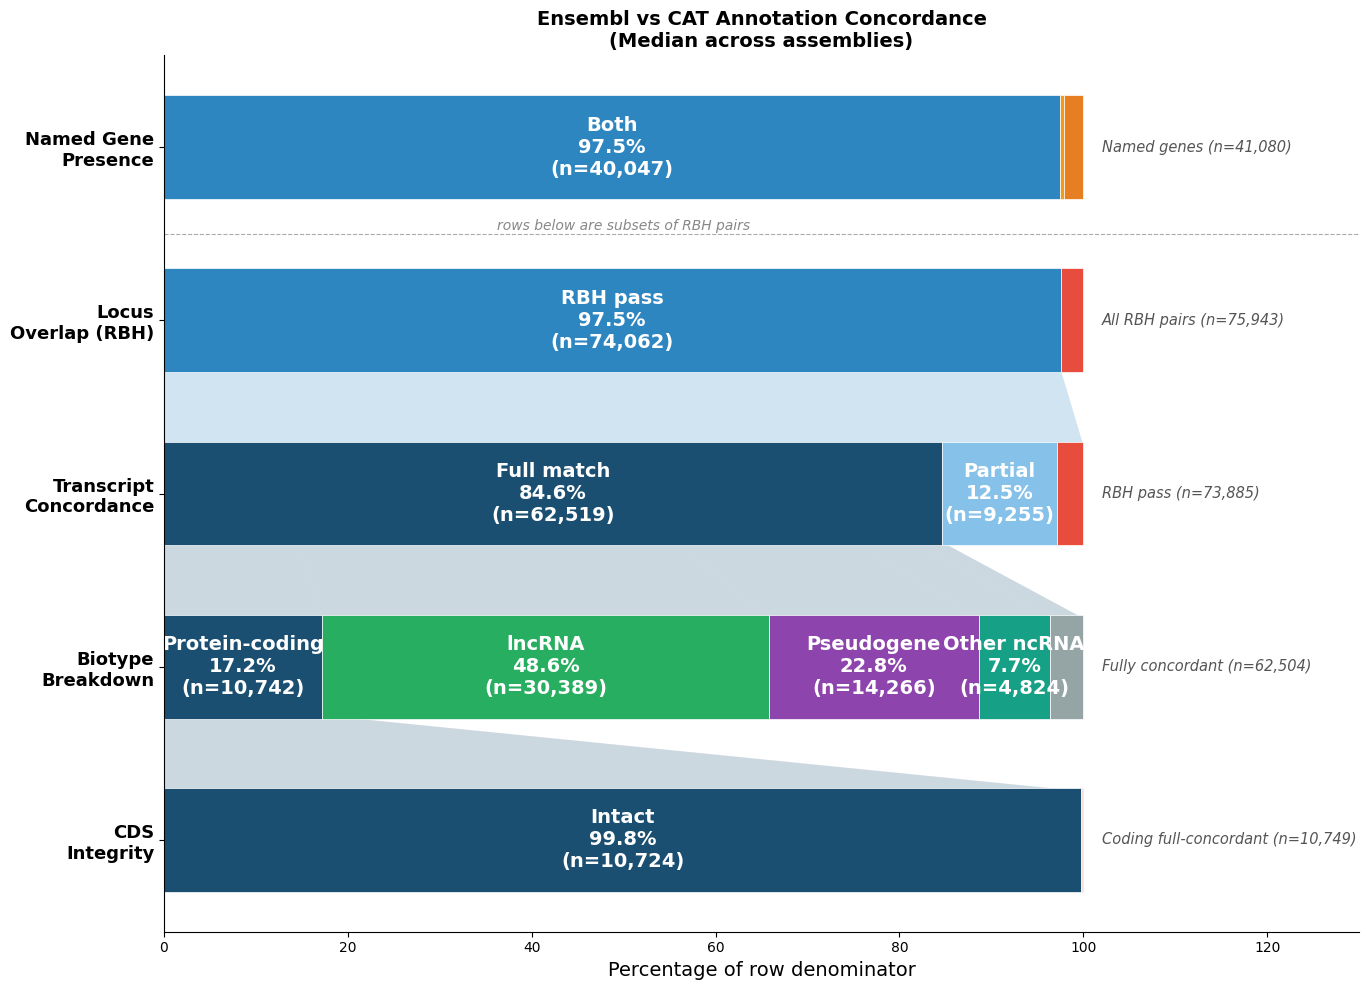

Saved to figures/figure_main1_sankey.png


In [27]:
# --- MAIN-1 Figure: 5-level stacked bar chart + flow ribbons ---
# Principle: each level's denominator is the "winning" subset of the level above.
#
#  L1  Named gene presence        denominator: all named genes
#  L2  RBH locus overlap          denominator: all RBH pairs (own)
#  L3  Transcript concordance     denominator: L2 RBH pass
#  L3b Biotype of fully concordant denominator: L3 full match
#  L4  CDS integrity              denominator: L3b protein-coding

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

def _segment_ranges(labels, pcts):
    out = {}
    left = 0.0
    for lab, pct in zip(labels, pcts):
        out[lab] = (left, left + float(pct))
        left += float(pct)
    return out

def _draw_ribbons_bottom_to_top(
    ax, y_upper_center, y_lower_center, bar_height,
    upper_labels, upper_pcts, lower_labels, lower_pcts,
    flow_counts, upper_color_map,
    alpha=0.28, zorder=0.7, y_gap=0.02,
):
    upper_ranges = _segment_ranges(upper_labels, upper_pcts)
    lower_ranges = _segment_ranges(lower_labels, lower_pcts)
    upper_cursor = {u: upper_ranges[u][0] for u in upper_labels}
    lower_cursor = {l: lower_ranges[l][0] for l in lower_labels}

    upper_den = {u: sum(flow_counts.get(u, {}).values()) for u in upper_labels}
    lower_den = {l: sum(flow_counts.get(u, {}).get(l, 0) for u in upper_labels) for l in lower_labels}

    def w_upper(u, c):
        seg_w = upper_ranges[u][1] - upper_ranges[u][0]
        return (c / upper_den[u]) * seg_w if upper_den[u] > 0 else 0.0

    def w_lower(l, c):
        seg_w = lower_ranges[l][1] - lower_ranges[l][0]
        return (c / lower_den[l]) * seg_w if lower_den[l] > 0 else 0.0

    y_upper_bottom = y_upper_center - bar_height / 2 + y_gap
    y_lower_top    = y_lower_center + bar_height / 2 - y_gap

    for u in upper_labels:
        for l in lower_labels:
            c = float(flow_counts.get(u, {}).get(l, 0) or 0)
            if c <= 0:
                continue
            x0 = upper_cursor[u];  x1 = x0 + w_upper(u, c);  upper_cursor[u] = x1
            x2 = lower_cursor[l];  x3 = x2 + w_lower(l, c);  lower_cursor[l] = x3
            ax.add_patch(Polygon(
                [(x0, y_upper_bottom), (x1, y_upper_bottom), (x3, y_lower_top), (x2, y_lower_top)],
                closed=True, facecolor=upper_color_map.get(u, '#999999'),
                edgecolor='none', alpha=alpha, zorder=zorder, clip_on=True,
            ))

# ── Build level data ──────────────────────────────────────────────────────────

named_total = medians['l1_named_both'] + medians['l1_named_ens_only'] + medians['l1_named_cat_only']
l1_vals   = [medians['l1_named_both'], medians['l1_named_ens_only'], medians['l1_named_cat_only']]
l1_pcts   = [v / named_total * 100 if named_total > 0 else 0 for v in l1_vals]
l1_colors = [COLORS['concordant'], COLORS['ensembl_only'], COLORS['cat_only']]
l1_labels = ['Both', 'Ensembl only', 'CAT only']

l2_vals   = [medians['l2_pass'], medians['l2_fail']]
l2_pcts   = [v / medians['l2_total'] * 100 if medians['l2_total'] > 0 else 0 for v in l2_vals]
l2_colors = [COLORS['concordant'], COLORS['discordant']]
l2_labels = ['RBH pass', 'No RBH']

l3_vals  = [medians['l3_full'], medians['l3_partial'], medians['l3_none']]
l3_total = sum(l3_vals)
l3_pcts  = [v / l3_total * 100 if l3_total > 0 else 0 for v in l3_vals]
l3_colors = [COLORS['high_confidence'], COLORS['partial'], COLORS['discordant']]
l3_labels = ['Full match', 'Partial', 'No match']

l3b_vals  = [medians['l3b_protein_coding'], medians['l3b_lncrna'],
             medians['l3b_pseudogene'], medians['l3b_other_ncrna'], medians['l3b_other']]
l3b_total = sum(l3b_vals)
l3b_pcts  = [v / l3b_total * 100 if l3b_total > 0 else 0 for v in l3b_vals]
l3b_colors = ['#1b4f72', '#27ae60', '#8e44ad', '#16a085', '#95a5a6']
l3b_labels = ['Protein-coding', 'lncRNA', 'Pseudogene', 'Other ncRNA', 'Other']

l4_vals  = [medians['l4_intact'], medians['l4_partial'], medians['l4_disrupted']]
l4_total = sum(l4_vals)
l4_pcts  = [v / l4_total * 100 if l4_total > 0 else 0 for v in l4_vals]
l4_colors = [COLORS['high_confidence'], COLORS['partial'], COLORS['discordant']]
l4_labels = ['Intact', 'Partial disruption', 'Disrupted']

# y positions: L1=4, L2=3, L3=2, L3b=1, L4=0
all_levels = [
    (l1_pcts, l1_colors, l1_labels, l1_vals, f'Named genes (n={int(named_total):,})'),
    (l2_pcts, l2_colors, l2_labels, l2_vals, f'All RBH pairs (n={int(medians["l2_total"]):,})'),
    (l3_pcts, l3_colors, l3_labels, l3_vals, f'RBH pass (n={int(l3_total):,})'),
    (l3b_pcts, l3b_colors, l3b_labels, l3b_vals, f'Fully concordant (n={int(l3b_total):,})'),
    (l4_pcts, l4_colors, l4_labels, l4_vals, f'Coding full-concordant (n={int(l4_total):,})'),
]
level_labels = [
    'Named Gene\nPresence',
    'Locus\nOverlap (RBH)',
    'Transcript\nConcordance',
    'Biotype\nBreakdown',
    'CDS\nIntegrity',
]

# ── Draw stacked bars ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))
bar_height = 0.6

for i, (pcts, colors, labels, vals, denom_label) in enumerate(all_levels):
    row_y = 4 - i
    left = 0.0
    for pct, color, label, val in zip(pcts, colors, labels, vals):
        ax.barh(row_y, pct, left=left, height=bar_height, color=color,
                edgecolor='white', linewidth=0.5, zorder=1.0)
        if pct > 5:
            ax.text(left + pct / 2, row_y,
                    f'{label}\n{pct:.1f}%\n(n={int(val):,})',
                    ha='center', va='center', fontsize=14, fontweight='bold',
                    color='white', zorder=2.0)
        left += float(pct)
    ax.text(102, row_y, denom_label, va='center', ha='left', fontsize=10.5,
            color='#555555', style='italic', zorder=2.0)

# Divider between L1 (y=4) and L2 (y=3) — L2 has its own denominator
ax.axhline(y=3.5, color='#aaaaaa', linewidth=0.8, linestyle='--', zorder=2.0)
ax.text(50, 3.52, 'rows below are subsets of RBH pairs', ha='center',
        fontsize=10, color='#888888', style='italic', zorder=2.0)

# ── Flow ribbons (each from bottom of upper bar → top of lower bar) ──────────

# L2 → L3: RBH pass distributes into transcript concordance categories
flow_23 = {
    'RBH pass': {'Full match': medians['l3_full'], 'Partial': medians['l3_partial'], 'No match': medians['l3_none']},
    'No RBH':   {'Full match': 0, 'Partial': 0, 'No match': 0},
}
_draw_ribbons_bottom_to_top(
    ax, y_upper_center=3, y_lower_center=2, bar_height=bar_height,
    upper_labels=l2_labels, upper_pcts=l2_pcts,
    lower_labels=l3_labels, lower_pcts=l3_pcts,
    flow_counts=flow_23,
    upper_color_map={'RBH pass': COLORS['concordant'], 'No RBH': COLORS['discordant']},
    alpha=0.22,
)

# L3 → L3b: "Full match" distributes by biotype; Partial/No match do not flow down
flow_33b = {
    'Full match': {lab: v for lab, v in zip(l3b_labels, l3b_vals)},
    'Partial':    {lab: 0 for lab in l3b_labels},
    'No match':   {lab: 0 for lab in l3b_labels},
}
_draw_ribbons_bottom_to_top(
    ax, y_upper_center=2, y_lower_center=1, bar_height=bar_height,
    upper_labels=l3_labels, upper_pcts=l3_pcts,
    lower_labels=l3b_labels, lower_pcts=l3b_pcts,
    flow_counts=flow_33b,
    upper_color_map={l: c for l, c in zip(l3_labels, l3_colors)},
    alpha=0.22,
)

# L3b → L4: only protein-coding flows into CDS integrity
flow_3b4 = {
    'Protein-coding': {'Intact': medians['l4_intact'], 'Partial disruption': medians['l4_partial'], 'Disrupted': medians['l4_disrupted']},
    'lncRNA':         {'Intact': 0, 'Partial disruption': 0, 'Disrupted': 0},
    'Pseudogene':     {'Intact': 0, 'Partial disruption': 0, 'Disrupted': 0},
    'Other ncRNA':    {'Intact': 0, 'Partial disruption': 0, 'Disrupted': 0},
    'Other':          {'Intact': 0, 'Partial disruption': 0, 'Disrupted': 0},
}
_draw_ribbons_bottom_to_top(
    ax, y_upper_center=1, y_lower_center=0, bar_height=bar_height,
    upper_labels=l3b_labels, upper_pcts=l3b_pcts,
    lower_labels=l4_labels, lower_pcts=l4_pcts,
    flow_counts=flow_3b4,
    upper_color_map={l: c for l, c in zip(l3b_labels, l3b_colors)},
    alpha=0.22,
)

# ── Styling ───────────────────────────────────────────────────────────────────
ax.set_yticks(range(5))
ax.set_yticklabels(list(reversed(level_labels)), fontsize=13, fontweight='bold')
ax.set_xlabel('Percentage of row denominator', fontsize=14)
ax.set_xlim(0, 130)
ax.set_title('Ensembl vs CAT Annotation Concordance\n(Median across assemblies)', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'figure_main1_sankey.png', dpi=300, bbox_inches='tight')
fig.savefig(OUTPUT_DIR / 'figure_main1_sankey.pdf', bbox_inches='tight')
plt.show()
print(f"Saved to {OUTPUT_DIR / 'figure_main1_sankey.png'}")

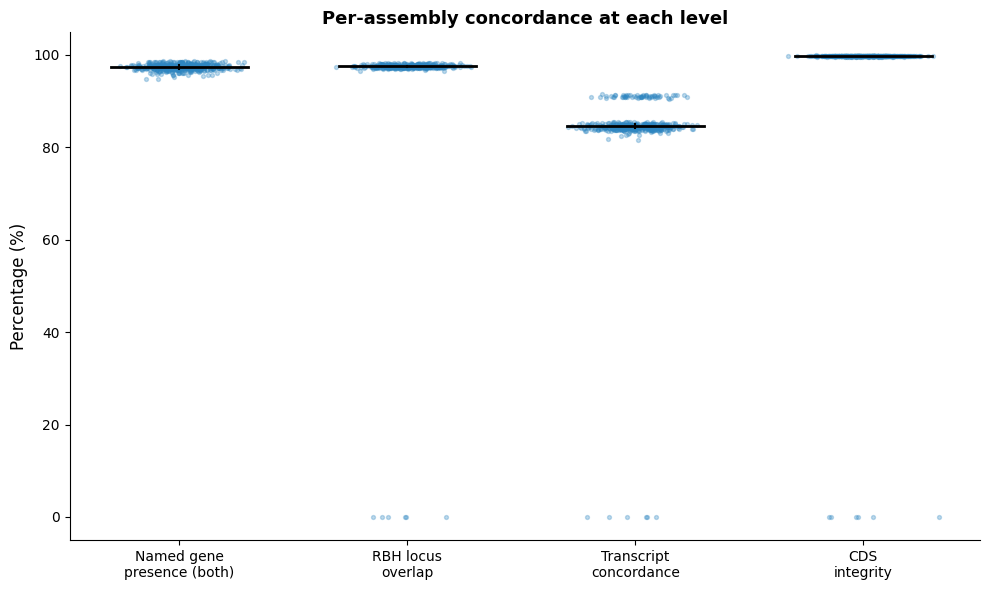

In [6]:
# --- Per-assembly distribution strip plot ---
fig, ax = plt.subplots(figsize=(10, 6))

pct_cols = ['l1_named_pct_both', 'l2_pct_pass', 'l3_pct_full', 'l4_pct_intact']
labels = ['Named gene\npresence (both)', 'RBH locus\noverlap', 'Transcript\nconcordance', 'CDS\nintegrity']

for i, (col, label) in enumerate(zip(pct_cols, labels)):
    vals = per_asm[col].dropna()
    jitter = np.random.normal(0, 0.1, len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals, alpha=0.3, s=8, color=COLORS['concordant'])
    med = vals.median()
    q25, q75 = vals.quantile(0.25), vals.quantile(0.75)
    ax.plot([i-0.3, i+0.3], [med, med], color='black', linewidth=2)
    ax.plot([i, i], [q25, q75], color='black', linewidth=1.5)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Per-assembly concordance at each level', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'figure_main1_per_assembly_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# --- DIAG 1: what objects / columns exist? ---
import pandas as pd
import numpy as np

objs = {k: v for k, v in globals().items() if k in ["per_asm", "medians", "df", "asm_delta", "by_biotype"]}
print("Available objects:", ", ".join(objs.keys()) if objs else "None of: per_asm, medians, df, asm_delta, by_biotype")

if "per_asm" in globals() and isinstance(per_asm, pd.DataFrame):
    print("\nper_asm shape:", per_asm.shape)
    print("per_asm columns (first 60):")
    print(list(per_asm.columns[:60]))
else:
    print("\nNo per_asm dataframe found. The strongest diagnostics need per-assembly counts.")

Available objects: per_asm, medians

per_asm shape: (462, 33)
per_asm columns (first 60):
['assembly_accession', 'sample_name', 'l1_total', 'l1_both', 'l1_ensembl_only', 'l1_cat_only', 'l1_pct_both', 'l1_named_total', 'l1_named_both', 'l1_named_ensembl_only', 'l1_named_cat_only', 'l1_named_pct_both', 'l2_rbh_total', 'l2_rbh_pass', 'l2_rbh_fail', 'l2_pct_pass', 'l3_tx_total', 'l3_tx_full', 'l3_tx_partial', 'l3_tx_none', 'l3_pct_full', 'l3b_total', 'l3b_protein_coding', 'l3b_lncrna', 'l3b_pseudogene', 'l3b_other_ncrna', 'l3b_other', 'l3b_pct_protein_coding', 'l4_cds_total', 'l4_cds_intact', 'l4_cds_partial', 'l4_cds_disrupted', 'l4_pct_intact']


In [11]:
# --- DIAG 2: auto-map columns needed for subset chain tests ---
import re

def _find_col(candidates, cols):
    """Return first matching column name from cols given list of regex/candidate strings."""
    for cand in candidates:
        # exact match
        if cand in cols:
            return cand
        # regex / contains match
        pat = re.compile(cand, flags=re.IGNORECASE)
        hits = [c for c in cols if pat.search(c)]
        if hits:
            # prefer shortest / most specific
            hits = sorted(hits, key=len)
            return hits[0]
    return None

if "per_asm" not in globals() or not isinstance(per_asm, pd.DataFrame):
    raise RuntimeError("per_asm is required for these diagnostics (per-assembly checks).")

cols = list(per_asm.columns)

# You can edit these if your column names differ.
COLMAP = {
    "assembly": _find_col([r"assembly_accession", r"assembly", r"asm"], cols),

    # L1
    "l1_named_both":     _find_col([r"l1_named_both", r"named.*both"], cols),
    "l1_named_ens_only": _find_col([r"l1_named_ens_only", r"named.*ens.*only", r"ensembl.*only.*named"], cols),
    "l1_named_cat_only": _find_col([r"l1_named_cat_only", r"named.*cat.*only", r"cat.*only.*named"], cols),

    # L2
    "l2_total": _find_col([r"l2_total", r"rbh.*total", r"total.*rbh"], cols),
    "l2_pass":  _find_col([r"l2_pass", r"rbh.*pass"], cols),
    "l2_fail":  _find_col([r"l2_fail", r"rbh.*fail", r"no.*rbh"], cols),

    # L3
    "l3_full":    _find_col([r"l3_full", r"full.*match", r"tx.*full"], cols),
    "l3_partial": _find_col([r"l3_partial", r"partial"], cols),
    "l3_none":    _find_col([r"l3_none", r"no.*match", r"none"], cols),

    # L3b
    "l3b_protein_coding": _find_col([r"l3b_protein_coding", r"protein.*coding"], cols),
    "l3b_lncrna":         _find_col([r"l3b_lncrna", r"lncRNA", r"lncrna"], cols),
    "l3b_pseudogene":     _find_col([r"l3b_pseudogene", r"pseudogene"], cols),
    "l3b_other_ncrna":    _find_col([r"l3b_other_ncrna", r"other.*ncRNA", r"other.*ncrna"], cols),
    "l3b_other":          _find_col([r"l3b_other", r"\bother\b"], cols),

    # L4
    "l4_intact":    _find_col([r"l4_intact", r"cds.*intact", r"intact"], cols),
    "l4_partial":   _find_col([r"l4_partial", r"partial.*disrupt"], cols),
    "l4_disrupted": _find_col([r"l4_disrupted", r"disrupt"], cols),
}

missing = [k for k, v in COLMAP.items() if v is None]
print("Column mapping:")
for k, v in COLMAP.items():
    print(f"  {k:18s} -> {v}")

if missing:
    print("\nMissing mappings:", missing)
    print("Edit COLMAP candidates above to match your per_asm column names.")
else:
    print("\nAll required columns mapped ✅")

Column mapping:
  assembly           -> assembly_accession
  l1_named_both      -> l1_named_both
  l1_named_ens_only  -> l1_named_ensembl_only
  l1_named_cat_only  -> l1_named_cat_only
  l2_total           -> l2_rbh_total
  l2_pass            -> l2_rbh_pass
  l2_fail            -> l2_rbh_fail
  l3_full            -> l3_tx_full
  l3_partial         -> l3_tx_partial
  l3_none            -> l3_tx_none
  l3b_protein_coding -> l3b_protein_coding
  l3b_lncrna         -> l3b_lncrna
  l3b_pseudogene     -> l3b_pseudogene
  l3b_other_ncrna    -> l3b_other_ncrna
  l3b_other          -> l3b_other
  l4_intact          -> l4_cds_intact
  l4_partial         -> None
  l4_disrupted       -> l4_cds_disrupted

Missing mappings: ['l4_partial']
Edit COLMAP candidates above to match your per_asm column names.


In [14]:
# --- DIAG A: patch COLMAP for l4_partial and (re)build d ---
import pandas as pd
import numpy as np

# Patch: your column is l4_cds_partial
COLMAP["l4_partial"] = "l4_cds_partial"

# Rebuild diagnostic working frame (same logic as DIAG 3, but with your known names)
asm_col = COLMAP["assembly"]

need = [
    "l2_pass", "l3_full", "l3_partial", "l3_none",
    "l3b_protein_coding", "l3b_lncrna", "l3b_pseudogene", "l3b_other_ncrna", "l3b_other",
    "l4_intact", "l4_partial", "l4_disrupted",
]

missing = [k for k in need if COLMAP.get(k) is None]
if missing:
    raise RuntimeError(f"Still missing mappings: {missing}")

d = per_asm[[asm_col] + [COLMAP[k] for k in need]].copy()
d = d.rename(columns={asm_col: "assembly"} | {COLMAP[k]: k for k in need})

# numeric
for k in need:
    d[k] = pd.to_numeric(d[k], errors="coerce")

print("OK: built diagnostic frame d with columns:")
print(d.columns.tolist())
print("Rows:", len(d))

OK: built diagnostic frame d with columns:
['assembly', 'l2_pass', 'l3_full', 'l3_partial', 'l3_none', 'l3b_protein_coding', 'l3b_lncrna', 'l3b_pseudogene', 'l3b_other_ncrna', 'l3b_other', 'l4_intact', 'l4_partial', 'l4_disrupted']
Rows: 462


In [15]:
# --- DIAG B: subset chain identities per assembly ---
import numpy as np
import pandas as pd

# L2 → L3 identity check
d["l3_sum"] = d["l3_full"] + d["l3_partial"] + d["l3_none"]
d["l3_gap"] = d["l2_pass"] - d["l3_sum"]

# L3 → L3b identity check
d["l3b_sum"] = (
    d["l3b_protein_coding"] + d["l3b_lncrna"] + d["l3b_pseudogene"] + d["l3b_other_ncrna"] + d["l3b_other"]
)
d["l3b_gap"] = d["l3_full"] - d["l3b_sum"]

# L3b → L4 identity check
d["l4_sum"] = d["l4_intact"] + d["l4_partial"] + d["l4_disrupted"]
d["l4_gap"] = d["l3b_protein_coding"] - d["l4_sum"]

def gap_summary(s):
    s = s.dropna()
    return pd.Series({
        "median": s.median(),
        "mean": s.mean(),
        "min": s.min(),
        "max": s.max(),
        "n_nonzero": int((s != 0).sum()),
        "n": int(len(s)),
    })

summary = pd.DataFrame({
    "L2→L3 gap (l2_pass - (full+partial+none))": gap_summary(d["l3_gap"]),
    "L3→L3b gap (l3_full - sum(biotypes))":      gap_summary(d["l3b_gap"]),
    "L3b→L4 gap (coding - (intact+partial+disrupted))": gap_summary(d["l4_gap"]),
}).T

display(summary)

# Worst offenders (absolute gap)
for col in ["l3_gap", "l3b_gap", "l4_gap"]:
    print(f"\nTop 10 offenders by |{col}|:")
    display(d.loc[d[col].abs().sort_values(ascending=False).head(10).index, ["assembly", col]])

,median,mean,min,max,n_nonzero,n
L2→L3 gap (l2_pass - (full+partial+none)),0.0,0.000000,0.0,0.0,0.0,462.0
L3→L3b gap (l3_full - sum(biotypes)),0.0,0.000000,0.0,0.0,0.0,462.0
L3b→L4 gap (coding - (intact+partial+disrupted)),-4.5,-4.902597,-20.0,0.0,456.0,462.0



Top 10 offenders by |l3_gap|:


,assembly,l3_gap
0,GCA_018466835.2,0
1,GCA_018466845.2,0
2,GCA_018466855.2,0
3,GCA_018466985.2,0
4,GCA_018467005.2,0
5,GCA_018467015.2,0
6,GCA_018467155.2,0
7,GCA_018467165.2,0
8,GCA_018469405.2,0
9,GCA_018469415.2,0



Top 10 offenders by |l3b_gap|:


,assembly,l3b_gap
0,GCA_018466835.2,0
1,GCA_018466845.2,0
2,GCA_018466855.2,0
3,GCA_018466985.2,0
4,GCA_018467005.2,0
5,GCA_018467015.2,0
6,GCA_018467155.2,0
7,GCA_018467165.2,0
8,GCA_018469405.2,0
9,GCA_018469415.2,0



Top 10 offenders by |l4_gap|:


,assembly,l4_gap
356,GCA_043304975.1,-20
301,GCA_042076875.1,-16
4,GCA_018467005.2,-15
169,GCA_042030125.1,-14
269,GCA_042037875.1,-13
248,GCA_042036525.1,-13
177,GCA_042030605.1,-12
349,GCA_042078085.1,-12
97,GCA_041900115.1,-11
175,GCA_042030255.1,-11


In [16]:
# --- DIAG L4-1: internal consistency + compare to l4_cds_total and l3b_protein_coding ---
import pandas as pd
import numpy as np

# bring in the extra column we need
x = per_asm[[
    "assembly_accession",
    "l3b_protein_coding",
    "l4_cds_total", "l4_cds_intact", "l4_cds_partial", "l4_cds_disrupted"
]].copy()

for c in x.columns[1:]:
    x[c] = pd.to_numeric(x[c], errors="coerce")

x["l4_sum"] = x["l4_cds_intact"] + x["l4_cds_partial"] + x["l4_cds_disrupted"]

# checks
x["chk_l4_total_minus_sum"] = x["l4_cds_total"] - x["l4_sum"]
x["gap_vs_pc"] = x["l3b_protein_coding"] - x["l4_sum"]
x["gap_vs_l4_total"] = x["l3b_protein_coding"] - x["l4_cds_total"]

print("How often does l4_cds_total equal intact+partial+disrupted?")
print(x["chk_l4_total_minus_sum"].value_counts(dropna=False).head(10))

print("\nSummary of gaps (protein_coding - l4_sum):")
display(x["gap_vs_pc"].describe())

print("\nSummary of (protein_coding - l4_cds_total):")
display(x["gap_vs_l4_total"].describe())

How often does l4_cds_total equal intact+partial+disrupted?
chk_l4_total_minus_sum
0    462
Name: count, dtype: int64

Summary of gaps (protein_coding - l4_sum):


count    462.000000
mean      -4.902597
std        2.358635
min      -20.000000
25%       -6.000000
50%       -4.500000
75%       -3.000000
max        0.000000
Name: gap_vs_pc, dtype: float64


Summary of (protein_coding - l4_cds_total):


count    462.000000
mean      -4.902597
std        2.358635
min      -20.000000
25%       -6.000000
50%       -4.500000
75%       -3.000000
max        0.000000
Name: gap_vs_l4_total, dtype: float64

In [17]:
# --- DIAG L4-2: show worst offenders with context columns ---
import pandas as pd

x2 = per_asm[[
    "assembly_accession",
    "l3_tx_full", "l3b_total", "l3b_protein_coding",
    "l4_cds_total", "l4_cds_intact", "l4_cds_partial", "l4_cds_disrupted"
]].copy()

for c in x2.columns[1:]:
    x2[c] = pd.to_numeric(x2[c], errors="coerce")

x2["l4_sum"] = x2["l4_cds_intact"] + x2["l4_cds_partial"] + x2["l4_cds_disrupted"]
x2["l4_gap"] = x2["l3b_protein_coding"] - x2["l4_sum"]
x2["pc_minus_l4total"] = x2["l3b_protein_coding"] - x2["l4_cds_total"]

worst = x2.sort_values("l4_gap").head(25)  # most negative first
display(worst)

,assembly_accession,l3_tx_full,l3b_total,l3b_protein_coding,l4_cds_total,l4_cds_intact,l4_cds_partial,l4_cds_disrupted,l4_sum,l4_gap,pc_minus_l4total
356,GCA_043304975.1,61043,61043,10516,10536,10498,9,29,10536,-20,-20
301,GCA_042076875.1,63016,63016,10860,10876,10837,8,31,10876,-16,-16
4,GCA_018467005.2,67198,67198,15576,15591,15557,11,23,15591,-15,-15
169,GCA_042030125.1,61238,61238,10765,10779,10746,7,26,10779,-14,-14
269,GCA_042037875.1,62493,62493,10669,10682,10648,9,25,10682,-13,-13
248,GCA_042036525.1,61740,61740,10351,10364,10322,10,32,10364,-13,-13
177,GCA_042030605.1,61923,61923,10354,10366,10338,10,18,10366,-12,-12
349,GCA_042078085.1,62821,62821,10718,10730,10697,8,25,10730,-12,-12
175,GCA_042030255.1,61410,61410,10061,10072,10045,9,18,10072,-11,-11
187,GCA_042031265.1,60309,60309,10122,10133,10106,8,19,10133,-11,-11


In [19]:
# --- DIAG (fixed): how often is L4 broader than L3b protein coding? ---
import pandas as pd
import numpy as np

tmp = per_asm[[
    "assembly_accession",
    "l3b_protein_coding",
    "l4_cds_total"
]].copy()

# Convert only numeric columns explicitly
for col in ["l3b_protein_coding", "l4_cds_total"]:
    tmp[col] = pd.to_numeric(tmp[col], errors="coerce")

tmp["delta"] = tmp["l4_cds_total"] - tmp["l3b_protein_coding"]

print("Assemblies where L4 > L3b_protein_coding:", (tmp["delta"] > 0).sum(), "/", len(tmp))
print("Median delta:", tmp["delta"].median())
print("Mean delta:", tmp["delta"].mean())
print("Min/Max delta:", tmp["delta"].min(), tmp["delta"].max())

display(tmp["delta"].value_counts().sort_index().head(20))

Assemblies where L4 > L3b_protein_coding: 456 / 462
Median delta: 4.5
Mean delta: 4.902597402597403
Min/Max delta: 0 20


delta
0       6
1       1
2      32
3      86
4     106
5      92
6      59
7      30
8      19
9      10
10      6
11      7
12      2
13      2
14      1
15      1
16      1
20      1
Name: count, dtype: int64

In [20]:
# --- DIAG: does L4 align better with L3_tx_full than L3b_protein_coding? ---
import pandas as pd
import numpy as np

chk = per_asm[[
    "assembly_accession",
    "l3_tx_full",
    "l3b_protein_coding",
    "l4_cds_total"
]].copy()

for c in chk.columns[1:]:
    chk[c] = pd.to_numeric(chk[c], errors="coerce")

chk["delta_vs_l3_full"] = chk["l4_cds_total"] - chk["l3_tx_full"]
chk["delta_vs_pc"]      = chk["l4_cds_total"] - chk["l3b_protein_coding"]

print("Median delta vs L3_full:", chk["delta_vs_l3_full"].median())
print("Median delta vs L3b_protein_coding:", chk["delta_vs_pc"].median())

display(chk[["delta_vs_l3_full","delta_vs_pc"]].describe())

Median delta vs L3_full: -51763.5
Median delta vs L3b_protein_coding: 4.5


,delta_vs_l3_full,delta_vs_pc
count,462.000000,462.000000
mean,-50957.898268,4.902597
std,5911.374463,2.358635
min,-53716.000000,0.000000
25%,-52018.750000,3.000000
50%,-51763.500000,4.500000
75%,-51336.500000,6.000000
max,0.000000,20.000000


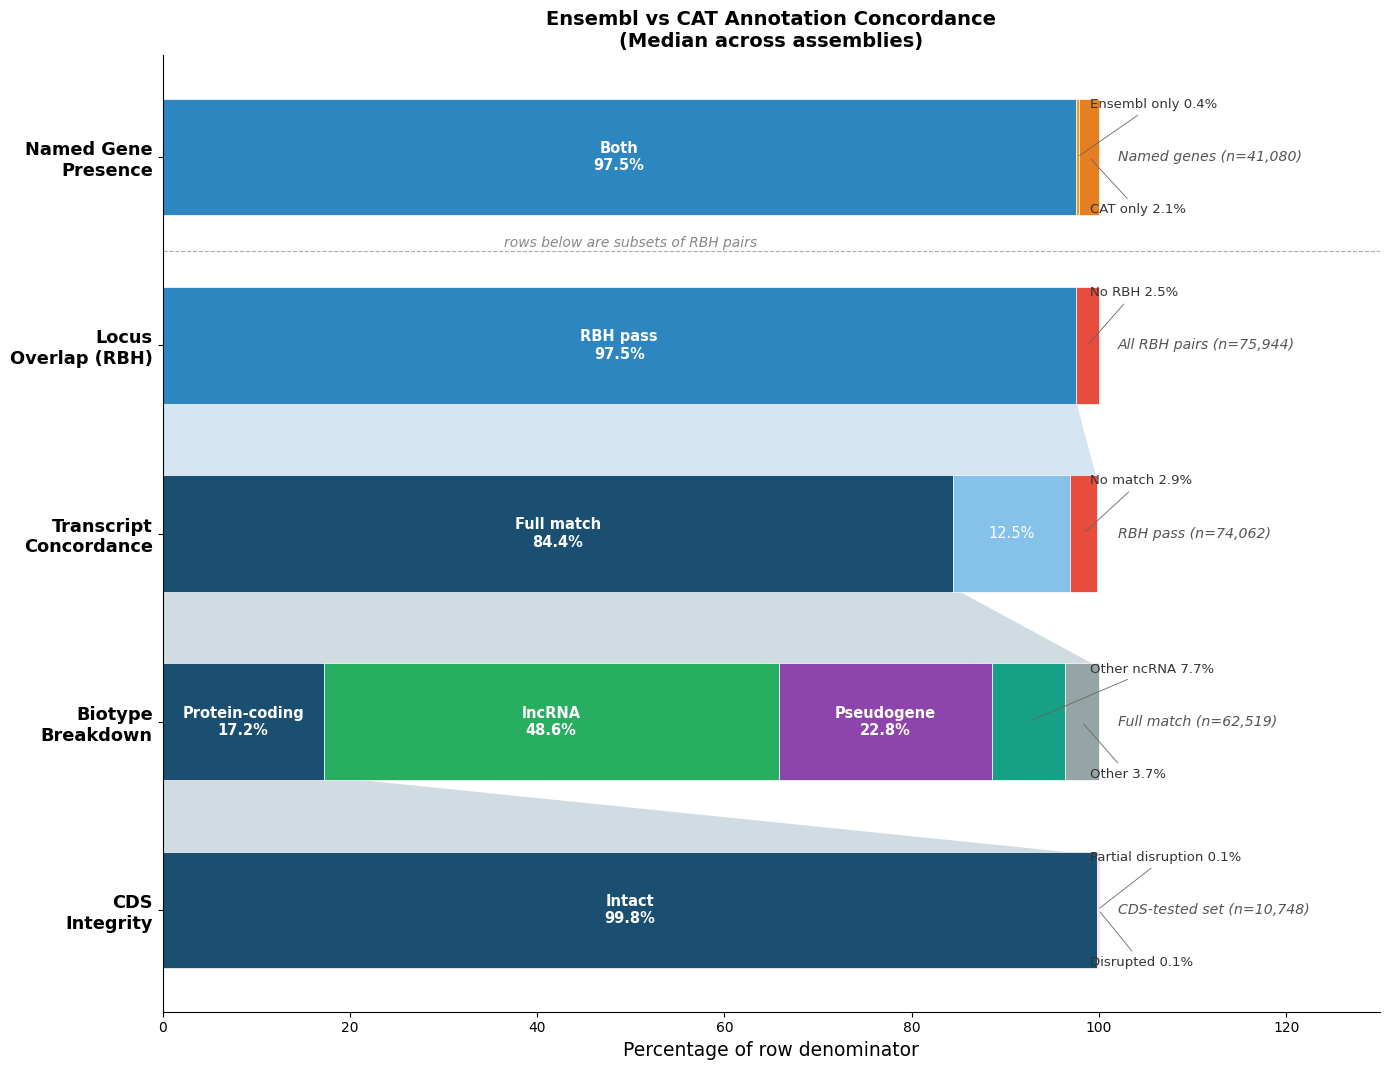

Saved to figures/figure_main1_sankey_corrected.png


In [30]:
# --- MAIN-1 Figure (corrected + robust medians keys): 5-level stacked bar chart + flow ribbons ---

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import pandas as pd
import numpy as np

# ---------------- key resolution helpers ----------------

def _mget(m, key, default=None):
    """Get from dict/Series-like medians safely."""
    try:
        return m[key]
    except Exception:
        return default

def _resolve_median_key(m, candidates):
    """Return first candidate key present in medians (dict/Series), else None."""
    for k in candidates:
        try:
            _ = m[k]
            return k
        except Exception:
            continue
    return None

def _median_from_per_asm(col):
    if "per_asm" not in globals():
        raise KeyError(f"Need per_asm to compute median for missing key: {col}")
    return float(pd.to_numeric(per_asm[col], errors="coerce").median())

def _get_median(m, key, candidates=(), per_asm_col=None):
    """
    Preferred: exact key in medians.
    Else: try candidates.
    Else: compute from per_asm_col if provided.
    """
    if key is not None:
        v = _mget(m, key, None)
        if v is not None:
            return float(v)

    k2 = _resolve_median_key(m, candidates)
    if k2 is not None:
        return float(m[k2])

    if per_asm_col is not None:
        return _median_from_per_asm(per_asm_col)

    raise KeyError(f"Could not find any of keys {([key] if key else []) + list(candidates)} and no per_asm_col fallback was provided.")

def _fmt_n(x):
    try:
        return f"{int(round(float(x))):,}"
    except Exception:
        return "NA"

# ---------------- ribbon helpers ----------------

def _segment_ranges(labels, widths):
    out, left = {}, 0.0
    for lab, w in zip(labels, widths):
        out[lab] = (left, left + float(w))
        left += float(w)
    return out

def _draw_ribbons_bottom_to_top(
    ax, y_upper_center, y_lower_center, bar_height,
    upper_labels, upper_widths, lower_labels, lower_widths,
    flow_counts, upper_color_map,
    alpha=0.20, zorder=0.65, y_gap=0.02,
):
    upper_ranges = _segment_ranges(upper_labels, upper_widths)
    lower_ranges = _segment_ranges(lower_labels, lower_widths)
    upper_cursor = {u: upper_ranges[u][0] for u in upper_labels}
    lower_cursor = {l: lower_ranges[l][0] for l in lower_labels}

    upper_den = {u: sum(flow_counts.get(u, {}).values()) for u in upper_labels}
    lower_den = {l: sum(flow_counts.get(u, {}).get(l, 0) for u in upper_labels) for l in lower_labels}

    def w_upper(u, c):
        seg_w = upper_ranges[u][1] - upper_ranges[u][0]
        return (c / upper_den[u]) * seg_w if upper_den[u] > 0 else 0.0

    def w_lower(l, c):
        seg_w = lower_ranges[l][1] - lower_ranges[l][0]
        return (c / lower_den[l]) * seg_w if lower_den[l] > 0 else 0.0

    y_upper_bottom = y_upper_center - bar_height / 2 + y_gap
    y_lower_top    = y_lower_center + bar_height / 2 - y_gap

    for u in upper_labels:
        for l in lower_labels:
            c = float(flow_counts.get(u, {}).get(l, 0) or 0)
            if c <= 0:
                continue
            x0 = upper_cursor[u]; x1 = x0 + w_upper(u, c); upper_cursor[u] = x1
            x2 = lower_cursor[l]; x3 = x2 + w_lower(l, c); lower_cursor[l] = x3
            ax.add_patch(Polygon(
                [(x0, y_upper_bottom), (x1, y_upper_bottom), (x3, y_lower_top), (x2, y_lower_top)],
                closed=True,
                facecolor=upper_color_map.get(u, "#999999"),
                edgecolor="none",
                alpha=alpha,
                zorder=zorder,
                clip_on=True,
            ))

# ---------------- pull medians robustly (including l4_cds_total) ----------------

# L1
m_l1_named_both = _get_median(medians, "l1_named_both", per_asm_col="l1_named_both")
m_l1_named_ens  = _get_median(medians, "l1_named_ens_only", candidates=("l1_named_ensembl_only",), per_asm_col="l1_named_ensembl_only")
m_l1_named_cat  = _get_median(medians, "l1_named_cat_only", per_asm_col="l1_named_cat_only")

# L2
m_l2_total = _get_median(medians, "l2_total", candidates=("l2_rbh_total",), per_asm_col="l2_rbh_total")
m_l2_pass  = _get_median(medians, "l2_pass",  candidates=("l2_rbh_pass",),  per_asm_col="l2_rbh_pass")
m_l2_fail  = _get_median(medians, "l2_fail",  candidates=("l2_rbh_fail",),  per_asm_col="l2_rbh_fail")

# L3
m_l3_full    = _get_median(medians, "l3_full",    candidates=("l3_tx_full",),    per_asm_col="l3_tx_full")
m_l3_partial = _get_median(medians, "l3_partial", candidates=("l3_tx_partial",), per_asm_col="l3_tx_partial")
m_l3_none    = _get_median(medians, "l3_none",    candidates=("l3_tx_none",),    per_asm_col="l3_tx_none")

# L3b
m_l3b_pc   = _get_median(medians, "l3b_protein_coding", per_asm_col="l3b_protein_coding")
m_l3b_ln   = _get_median(medians, "l3b_lncrna",         per_asm_col="l3b_lncrna")
m_l3b_ps   = _get_median(medians, "l3b_pseudogene",     per_asm_col="l3b_pseudogene")
m_l3b_onc  = _get_median(medians, "l3b_other_ncrna",    per_asm_col="l3b_other_ncrna")
m_l3b_oth  = _get_median(medians, "l3b_other",          per_asm_col="l3b_other")

# L4 (THIS is the one that failed): try multiple likely key names, else compute from per_asm
m_l4_cds_total = _get_median(
    medians,
    "l4_cds_total",
    candidates=("l4_total", "l4_total_cds", "l4_cds_total_median", "l4_cds_total_med"),
    per_asm_col="l4_cds_total"
)
m_l4_intact = _get_median(medians, "l4_intact", candidates=("l4_cds_intact",), per_asm_col="l4_cds_intact")
m_l4_part   = _get_median(medians, "l4_partial", candidates=("l4_cds_partial",), per_asm_col="l4_cds_partial")
m_l4_disr   = _get_median(medians, "l4_disrupted", candidates=("l4_cds_disrupted",), per_asm_col="l4_cds_disrupted")

# ---------------- build bar widths (percent units) with correct denominators ----------------

# L1
named_total = m_l1_named_both + m_l1_named_ens + m_l1_named_cat
l1_vals   = [m_l1_named_both, m_l1_named_ens, m_l1_named_cat]
l1_pcts   = [v / named_total * 100 if named_total > 0 else 0 for v in l1_vals]
l1_colors = [COLORS["concordant"], COLORS["ensembl_only"], COLORS["cat_only"]]
l1_labels = ["Both", "Ensembl only", "CAT only"]

# L2 (denom is all RBH pairs)
l2_vals   = [m_l2_pass, m_l2_fail]
l2_pcts   = [v / m_l2_total * 100 if m_l2_total > 0 else 0 for v in l2_vals]
l2_colors = [COLORS["concordant"], COLORS["discordant"]]
l2_labels = ["RBH pass", "No RBH"]

# L3 (denom is RBH pass)
l3_vals   = [m_l3_full, m_l3_partial, m_l3_none]
l3_den    = m_l2_pass
l3_pcts   = [v / l3_den * 100 if l3_den > 0 else 0 for v in l3_vals]
l3_colors = [COLORS["high_confidence"], COLORS["partial"], COLORS["discordant"]]
l3_labels = ["Full match", "Partial", "No match"]

# L3b (denom is L3 full)
l3b_vals   = [m_l3b_pc, m_l3b_ln, m_l3b_ps, m_l3b_onc, m_l3b_oth]
l3b_den    = m_l3_full
l3b_pcts   = [v / l3b_den * 100 if l3b_den > 0 else 0 for v in l3b_vals]
l3b_colors = ["#1b4f72", "#27ae60", "#8e44ad", "#16a085", "#95a5a6"]
l3b_labels = ["Protein-coding", "lncRNA", "Pseudogene", "Other ncRNA", "Other"]

# L4 (denom is CDS total; add optional "Other CDS-tested" wedge if cds_total > sum(parts))
l4_vals_base = [m_l4_intact, m_l4_part, m_l4_disr]
l4_den       = m_l4_cds_total
l4_extra     = max(0.0, float(l4_den) - float(sum(l4_vals_base)))
l4_vals      = l4_vals_base + ([l4_extra] if l4_extra > 0 else [])
l4_labels    = ["Intact", "Partial disruption", "Disrupted"] + (["Other CDS-tested"] if l4_extra > 0 else [])
l4_colors    = [COLORS["high_confidence"], COLORS["partial"], COLORS["discordant"]] + (["#b3b3b3"] if l4_extra > 0 else [])
l4_pcts      = [v / l4_den * 100 if l4_den > 0 else 0 for v in l4_vals]

# ---------------- plotting ----------------

fig, ax = plt.subplots(figsize=(14, 10.8))
bar_height = 0.62

# label policy
INSIDE_LABEL_PCT = 14.0
INSIDE_PCT_ONLY  = 8.0
FONT_INSIDE = 10.5
FONT_OUTSIDE = 9.5

all_levels = [
    (l1_pcts, l1_colors, l1_labels, l1_vals, f"Named genes (n={_fmt_n(named_total)})"),
    (l2_pcts, l2_colors, l2_labels, l2_vals, f"All RBH pairs (n={_fmt_n(m_l2_total)})"),
    (l3_pcts, l3_colors, l3_labels, l3_vals, f"RBH pass (n={_fmt_n(m_l2_pass)})"),
    (l3b_pcts, l3b_colors, l3b_labels, l3b_vals, f"Full match (n={_fmt_n(m_l3_full)})"),
    (l4_pcts, l4_colors, l4_labels, l4_vals, f"CDS-tested set (n={_fmt_n(l4_den)})"),
]
level_labels = [
    "Named Gene\nPresence",
    "Locus\nOverlap (RBH)",
    "Transcript\nConcordance",
    "Biotype\nBreakdown",
    "CDS\nIntegrity",
]

for i, (pcts, colors, labels, vals, denom_label) in enumerate(all_levels):
    row_y = 4 - i
    left = 0.0
    small_ann = []

    for pct, color, lab, val in zip(pcts, colors, labels, vals):
        ax.barh(
            row_y, pct, left=left, height=bar_height,
            color=color, edgecolor="white", linewidth=0.5, zorder=1.0
        )
        mid = left + pct / 2

        if pct >= INSIDE_LABEL_PCT:
            ax.text(mid, row_y, f"{lab}\n{pct:.1f}%",
                    ha="center", va="center",
                    fontsize=FONT_INSIDE, fontweight="bold",
                    color="white", zorder=2.2)
        elif pct >= INSIDE_PCT_ONLY:
            ax.text(mid, row_y, f"{pct:.1f}%",
                    ha="center", va="center",
                    fontsize=FONT_INSIDE,
                    color="white", zorder=2.2)
        else:
            small_ann.append((lab, pct, left, left + pct))

        left += float(pct)

    ax.text(102, row_y, denom_label, va="center", ha="left",
            fontsize=10.2, color="#555555", style="italic", zorder=2.2)

    # Outside labels for small segments (cap to avoid clutter)
    if small_ann:
        small_ann = sorted(small_ann, key=lambda t: (t[2] + t[3]) / 2)
        offsets = [0.28, -0.28, 0.42, -0.42, 0.56, -0.56]
        for j, (lab, pct, x0, x1) in enumerate(small_ann[:6]):
            xmid = (x0 + x1) / 2
            ytxt = row_y + offsets[j % len(offsets)]
            ax.annotate(
                f"{lab} {pct:.1f}%",
                xy=(xmid, row_y),
                xytext=(min(99.0, xmid + 8.0), ytxt),
                textcoords="data",
                ha="left", va="center",
                fontsize=FONT_OUTSIDE, color="#333333",
                arrowprops=dict(arrowstyle="-", lw=0.6, color="#666666"),
                zorder=2.3,
                clip_on=False,
            )

# Divider between L1 and L2
ax.axhline(y=3.5, color="#aaaaaa", linewidth=0.8, linestyle="--", zorder=2.0)
ax.text(50, 3.52, "rows below are subsets of RBH pairs",
        ha="center", fontsize=10, color="#888888", style="italic", zorder=2.0)

# ---------------- ribbons ----------------

# L2 → L3
flow_23 = {
    "RBH pass": {"Full match": m_l3_full, "Partial": m_l3_partial, "No match": m_l3_none},
    "No RBH":   {"Full match": 0, "Partial": 0, "No match": 0},
}
_draw_ribbons_bottom_to_top(
    ax,
    y_upper_center=3, y_lower_center=2, bar_height=bar_height,
    upper_labels=l2_labels, upper_widths=l2_pcts,
    lower_labels=l3_labels, lower_widths=l3_pcts,
    flow_counts=flow_23,
    upper_color_map={"RBH pass": COLORS["concordant"], "No RBH": COLORS["discordant"]},
    alpha=0.20,
)

# L3 → L3b
flow_33b = {
    "Full match": {lab: v for lab, v in zip(l3b_labels, l3b_vals)},
    "Partial":    {lab: 0 for lab in l3b_labels},
    "No match":   {lab: 0 for lab in l3b_labels},
}
_draw_ribbons_bottom_to_top(
    ax,
    y_upper_center=2, y_lower_center=1, bar_height=bar_height,
    upper_labels=l3_labels, upper_widths=l3_pcts,
    lower_labels=l3b_labels, lower_widths=l3b_pcts,
    flow_counts=flow_33b,
    upper_color_map={lab: col for lab, col in zip(l3_labels, l3_colors)},
    alpha=0.20,
)

# L3b → L4 (protein-coding flows; optional grey wedge receives "Other CDS-tested")
flow_3b4 = {
    "Protein-coding": {
        "Intact": m_l4_intact,
        "Partial disruption": m_l4_part,
        "Disrupted": m_l4_disr,
        **({"Other CDS-tested": l4_extra} if l4_extra > 0 else {}),
    },
    "lncRNA":      {lab: 0 for lab in l4_labels},
    "Pseudogene":  {lab: 0 for lab in l4_labels},
    "Other ncRNA": {lab: 0 for lab in l4_labels},
    "Other":       {lab: 0 for lab in l4_labels},
}
_draw_ribbons_bottom_to_top(
    ax,
    y_upper_center=1, y_lower_center=0, bar_height=bar_height,
    upper_labels=l3b_labels, upper_widths=l3b_pcts,
    lower_labels=l4_labels, lower_widths=l4_pcts,
    flow_counts=flow_3b4,
    upper_color_map={lab: col for lab, col in zip(l3b_labels, l3b_colors)},
    alpha=0.20,
)

# ---------------- styling ----------------
ax.set_yticks(range(5))
ax.set_yticklabels(list(reversed(level_labels)), fontsize=12.8, fontweight="bold")
ax.set_xlabel("Percentage of row denominator", fontsize=13.5)
ax.set_xlim(0, 130)
ax.set_title("Ensembl vs CAT Annotation Concordance\n(Median across assemblies)",
             fontsize=14, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

if l4_extra > 0:
    ax.text(
        0, -0.8,
        "Note: 'Other CDS-tested' captures loci included in CDS checks beyond strict full-concordant protein-coding (~0–20 per assembly).",
        fontsize=9.3, color="#555555", style="italic"
    )

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "figure_main1_sankey_corrected.png", dpi=300, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "figure_main1_sankey_corrected.pdf", bbox_inches="tight")
plt.show()

print(f"Saved to {OUTPUT_DIR / 'figure_main1_sankey_corrected.png'}")

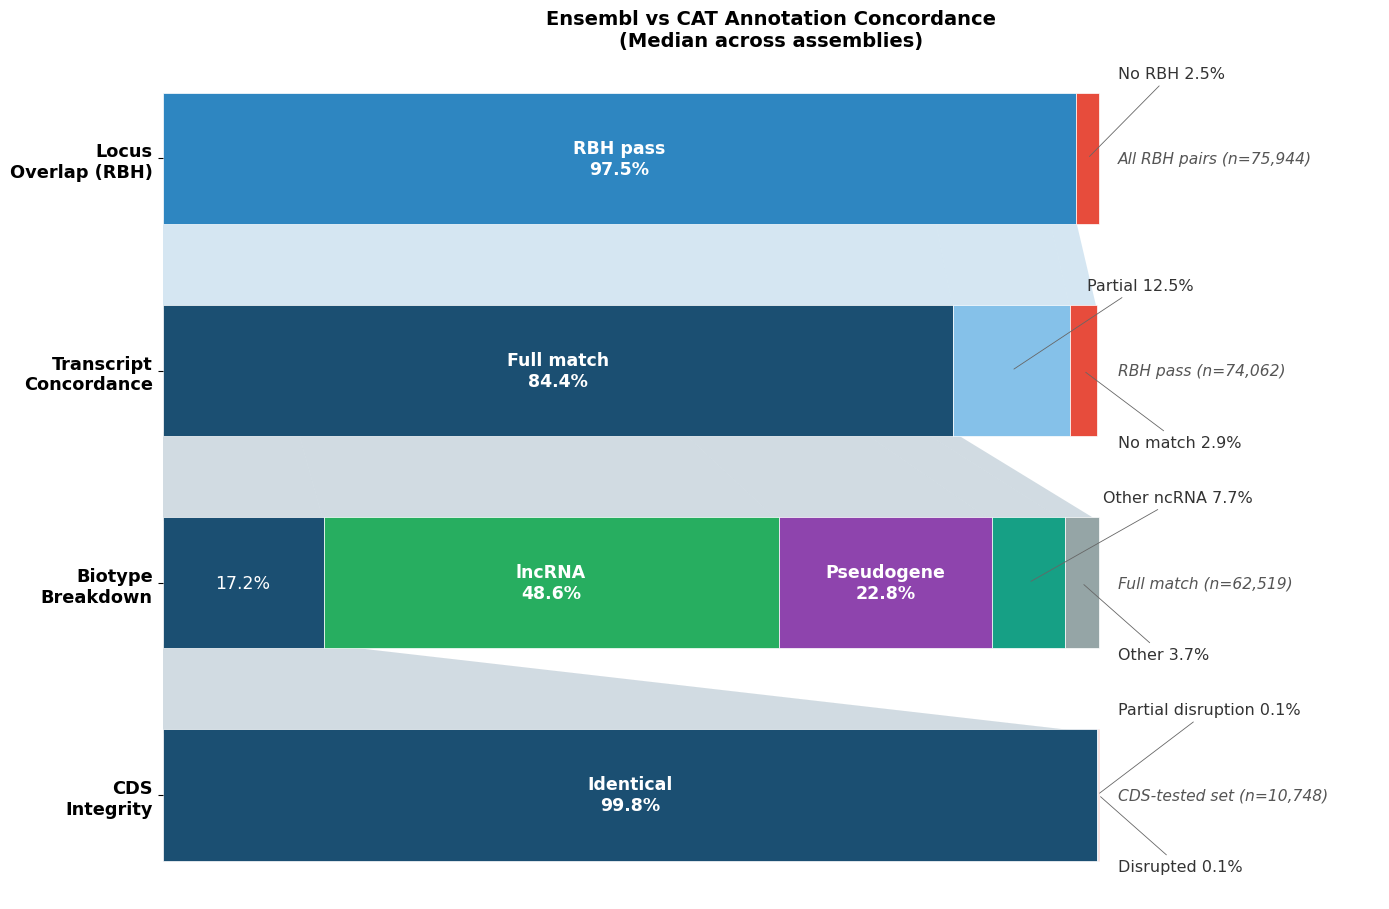

Saved to figures/figure_main1_sankey_corrected_no_l1.png


In [57]:
# --- MAIN-1 Figure (corrected + robust medians keys): 4-level stacked bar chart + flow ribbons (NO gene-presence rung) ---

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import pandas as pd
import numpy as np

# ---------------- key resolution helpers ----------------

def _mget(m, key, default=None):
    """Get from dict/Series-like medians safely."""
    try:
        return m[key]
    except Exception:
        return default

def _resolve_median_key(m, candidates):
    """Return first candidate key present in medians (dict/Series), else None."""
    for k in candidates:
        try:
            _ = m[k]
            return k
        except Exception:
            continue
    return None

def _median_from_per_asm(col):
    if "per_asm" not in globals():
        raise KeyError(f"Need per_asm to compute median for missing key: {col}")
    return float(pd.to_numeric(per_asm[col], errors="coerce").median())

def _get_median(m, key, candidates=(), per_asm_col=None):
    """
    Preferred: exact key in medians.
    Else: try candidates.
    Else: compute from per_asm_col if provided.
    """
    if key is not None:
        v = _mget(m, key, None)
        if v is not None:
            return float(v)

    k2 = _resolve_median_key(m, candidates)
    if k2 is not None:
        return float(m[k2])

    if per_asm_col is not None:
        return _median_from_per_asm(per_asm_col)

    raise KeyError(
        f"Could not find any of keys {([key] if key else []) + list(candidates)} "
        f"and no per_asm_col fallback was provided."
    )

def _fmt_n(x):
    try:
        return f"{int(round(float(x))):,}"
    except Exception:
        return "NA"

# ---------------- ribbon helpers ----------------

def _segment_ranges(labels, widths):
    out, left = {}, 0.0
    for lab, w in zip(labels, widths):
        out[lab] = (left, left + float(w))
        left += float(w)
    return out

def _draw_ribbons_bottom_to_top(
    ax, y_upper_center, y_lower_center, bar_height,
    upper_labels, upper_widths, lower_labels, lower_widths,
    flow_counts, upper_color_map,
    alpha=0.20, zorder=0.65, y_gap=0.02,
):
    upper_ranges = _segment_ranges(upper_labels, upper_widths)
    lower_ranges = _segment_ranges(lower_labels, lower_widths)
    upper_cursor = {u: upper_ranges[u][0] for u in upper_labels}
    lower_cursor = {l: lower_ranges[l][0] for l in lower_labels}

    upper_den = {u: sum(flow_counts.get(u, {}).values()) for u in upper_labels}
    lower_den = {
        l: sum(flow_counts.get(u, {}).get(l, 0) for u in upper_labels)
        for l in lower_labels
    }

    def w_upper(u, c):
        seg_w = upper_ranges[u][1] - upper_ranges[u][0]
        return (c / upper_den[u]) * seg_w if upper_den[u] > 0 else 0.0

    def w_lower(l, c):
        seg_w = lower_ranges[l][1] - lower_ranges[l][0]
        return (c / lower_den[l]) * seg_w if lower_den[l] > 0 else 0.0

    y_upper_bottom = y_upper_center - bar_height / 2 + y_gap
    y_lower_top    = y_lower_center + bar_height / 2 - y_gap

    for u in upper_labels:
        for l in lower_labels:
            c = float(flow_counts.get(u, {}).get(l, 0) or 0)
            if c <= 0:
                continue
            x0 = upper_cursor[u]; x1 = x0 + w_upper(u, c); upper_cursor[u] = x1
            x2 = lower_cursor[l]; x3 = x2 + w_lower(l, c); lower_cursor[l] = x3
            ax.add_patch(Polygon(
                [(x0, y_upper_bottom), (x1, y_upper_bottom), (x3, y_lower_top), (x2, y_lower_top)],
                closed=True,
                facecolor=upper_color_map.get(u, "#999999"),
                edgecolor="none",
                alpha=alpha,
                zorder=zorder,
                clip_on=True,
            ))

# ---------------- pull medians robustly ----------------

# L2
m_l2_total = _get_median(medians, "l2_total", candidates=("l2_rbh_total",), per_asm_col="l2_rbh_total")
m_l2_pass  = _get_median(medians, "l2_pass",  candidates=("l2_rbh_pass",),  per_asm_col="l2_rbh_pass")
m_l2_fail  = _get_median(medians, "l2_fail",  candidates=("l2_rbh_fail",),  per_asm_col="l2_rbh_fail")

# L3
m_l3_full    = _get_median(medians, "l3_full",    candidates=("l3_tx_full",),    per_asm_col="l3_tx_full")
m_l3_partial = _get_median(medians, "l3_partial", candidates=("l3_tx_partial",), per_asm_col="l3_tx_partial")
m_l3_none    = _get_median(medians, "l3_none",    candidates=("l3_tx_none",),    per_asm_col="l3_tx_none")

# L3b
m_l3b_pc   = _get_median(medians, "l3b_protein_coding", per_asm_col="l3b_protein_coding")
m_l3b_ln   = _get_median(medians, "l3b_lncrna",         per_asm_col="l3b_lncrna")
m_l3b_ps   = _get_median(medians, "l3b_pseudogene",     per_asm_col="l3b_pseudogene")
m_l3b_onc  = _get_median(medians, "l3b_other_ncrna",    per_asm_col="l3b_other_ncrna")
m_l3b_oth  = _get_median(medians, "l3b_other",          per_asm_col="l3b_other")

# L4
m_l4_cds_total = _get_median(
    medians,
    "l4_cds_total",
    candidates=("l4_total", "l4_total_cds", "l4_cds_total_median", "l4_cds_total_med"),
    per_asm_col="l4_cds_total"
)
m_l4_intact = _get_median(medians, "l4_intact", candidates=("l4_cds_intact",), per_asm_col="l4_cds_intact")
m_l4_part   = _get_median(medians, "l4_partial", candidates=("l4_cds_partial",), per_asm_col="l4_cds_partial")
m_l4_disr   = _get_median(medians, "l4_disrupted", candidates=("l4_cds_disrupted",), per_asm_col="l4_cds_disrupted")

# ---------------- build bar widths (percent units) with correct denominators ----------------

# L2 (denom is all RBH pairs)
l2_vals   = [m_l2_pass, m_l2_fail]
l2_pcts   = [v / m_l2_total * 100 if m_l2_total > 0 else 0 for v in l2_vals]
l2_colors = [COLORS["concordant"], COLORS["discordant"]]
l2_labels = ["RBH pass", "No RBH"]

# L3 (denom is RBH pass)
l3_vals   = [m_l3_full, m_l3_partial, m_l3_none]
l3_den    = m_l2_pass
l3_pcts   = [v / l3_den * 100 if l3_den > 0 else 0 for v in l3_vals]
l3_colors = [COLORS["high_confidence"], COLORS["partial"], COLORS["discordant"]]
l3_labels = ["Full match", "Partial", "No match"]

# L3b (denom is L3 full)
l3b_vals   = [m_l3b_pc, m_l3b_ln, m_l3b_ps, m_l3b_onc, m_l3b_oth]
l3b_den    = m_l3_full
l3b_pcts   = [v / l3b_den * 100 if l3b_den > 0 else 0 for v in l3b_vals]
l3b_colors = ["#1b4f72", "#27ae60", "#8e44ad", "#16a085", "#95a5a6"]
l3b_labels = ["Protein-coding", "lncRNA", "Pseudogene", "Other ncRNA", "Other"]

# L4 (denom is CDS total; add optional "Other CDS-tested" wedge if cds_total > sum(parts))
l4_vals_base = [m_l4_intact, m_l4_part, m_l4_disr]
l4_den       = m_l4_cds_total
l4_extra     = max(0.0, float(l4_den) - float(sum(l4_vals_base)))
l4_vals      = l4_vals_base + ([l4_extra] if l4_extra > 0 else [])
l4_labels    = ["Identical", "Partial disruption", "Disrupted"] + (["Other CDS-tested"] if l4_extra > 0 else [])
l4_colors    = [COLORS["high_confidence"], COLORS["partial"], COLORS["discordant"]] + (["#b3b3b3"] if l4_extra > 0 else [])
l4_pcts      = [v / l4_den * 100 if l4_den > 0 else 0 for v in l4_vals]

# ---------------- plotting ----------------

fig, ax = plt.subplots(figsize=(14, 9.2))
bar_height = 0.62

# label policy
INSIDE_LABEL_PCT = 20.0
INSIDE_PCT_ONLY  = 15.0
FONT_INSIDE = 12.5
FONT_OUTSIDE = 11.5

all_levels = [
    (l2_pcts,  l2_colors,  l2_labels,  l2_vals,  f"All RBH pairs (n={_fmt_n(m_l2_total)})"),
    (l3_pcts,  l3_colors,  l3_labels,  l3_vals,  f"RBH pass (n={_fmt_n(m_l2_pass)})"),
    (l3b_pcts, l3b_colors, l3b_labels, l3b_vals, f"Full match (n={_fmt_n(m_l3_full)})"),
    (l4_pcts,  l4_colors,  l4_labels,  l4_vals,  f"CDS-tested set (n={_fmt_n(l4_den)})"),
]
level_labels = [
    "Locus\nOverlap (RBH)",
    "Transcript\nConcordance",
    "Biotype\nBreakdown",
    "CDS\nIntegrity",
]

for i, (pcts, colors, labels, vals, denom_label) in enumerate(all_levels):
    row_y = 3 - i  # 4 rows: 3,2,1,0
    left = 0.0
    small_ann = []

    for pct, color, lab, val in zip(pcts, colors, labels, vals):
        ax.barh(
            row_y, pct, left=left, height=bar_height,
            color=color, edgecolor="white", linewidth=0.5, zorder=1.0
        )
        mid = left + pct / 2

        if pct >= INSIDE_LABEL_PCT:
            ax.text(mid, row_y, f"{lab}\n{pct:.1f}%",
                    ha="center", va="center",
                    fontsize=FONT_INSIDE, fontweight="bold",
                    color="white", zorder=2.2)
        elif pct >= INSIDE_PCT_ONLY:
            ax.text(mid, row_y, f"{pct:.1f}%",
                    ha="center", va="center",
                    fontsize=FONT_INSIDE,
                    color="white", zorder=2.2)
        else:
            small_ann.append((lab, pct, left, left + pct))

        left += float(pct)

    ax.text(102, row_y, denom_label, va="center", ha="left",
            fontsize=11.2, color="#555555", style="italic", zorder=2.2)

    ANN_X_OFFSET = 8.0
    # Outside labels for small segments (cap to avoid clutter)
    if small_ann:
        small_ann = sorted(small_ann, key=lambda t: (t[2] + t[3]) / 2)
        offsets = [0.40, -0.340, 0.42, -0.42, 0.66, -0.66]
        for j, (lab, pct, x0, x1) in enumerate(small_ann[:6]):
            xmid = (x0 + x1) / 2
            ytxt = row_y + offsets[j % len(offsets)]
            ax.annotate(
                f"{lab} {pct:.1f}%",
                xy=(xmid, row_y),
                xytext=(min(102.0, xmid + ANN_X_OFFSET), ytxt),
                textcoords="data",
                ha="left", va="center",
                fontsize=FONT_OUTSIDE, color="#333333",
                arrowprops=dict(arrowstyle="-", lw=0.6, color="#666666"),
                zorder=2.3,
                clip_on=False,
            )


# ---------------- ribbons ----------------

# L2 → L3
flow_23 = {
    "RBH pass": {"Full match": m_l3_full, "Partial": m_l3_partial, "No match": m_l3_none},
    "No RBH":   {"Full match": 0, "Partial": 0, "No match": 0},
}
_draw_ribbons_bottom_to_top(
    ax,
    y_upper_center=3, y_lower_center=2, bar_height=bar_height,
    upper_labels=l2_labels, upper_widths=l2_pcts,
    lower_labels=l3_labels, lower_widths=l3_pcts,
    flow_counts=flow_23,
    upper_color_map={"RBH pass": COLORS["concordant"], "No RBH": COLORS["discordant"]},
    alpha=0.20,
)

# L3 → L3b
flow_33b = {
    "Full match": {lab: v for lab, v in zip(l3b_labels, l3b_vals)},
    "Partial":    {lab: 0 for lab in l3b_labels},
    "No match":   {lab: 0 for lab in l3b_labels},
}
_draw_ribbons_bottom_to_top(
    ax,
    y_upper_center=2, y_lower_center=1, bar_height=bar_height,
    upper_labels=l3_labels, upper_widths=l3_pcts,
    lower_labels=l3b_labels, lower_widths=l3b_pcts,
    flow_counts=flow_33b,
    upper_color_map={lab: col for lab, col in zip(l3_labels, l3_colors)},
    alpha=0.20,
)

# L3b → L4 (protein-coding flows; optional grey wedge receives "Other CDS-tested")
flow_3b4 = {
    "Protein-coding": {
        "Identical": m_l4_intact,
        "Partial disruption": m_l4_part,
        "Disrupted": m_l4_disr,
        **({"Other CDS-tested": l4_extra} if l4_extra > 0 else {}),
    },
    "lncRNA":      {lab: 0 for lab in l4_labels},
    "Pseudogene":  {lab: 0 for lab in l4_labels},
    "Other ncRNA": {lab: 0 for lab in l4_labels},
    "Other":       {lab: 0 for lab in l4_labels},
}
_draw_ribbons_bottom_to_top(
    ax,
    y_upper_center=1, y_lower_center=0, bar_height=bar_height,
    upper_labels=l3b_labels, upper_widths=l3b_pcts,
    lower_labels=l4_labels, lower_widths=l4_pcts,
    flow_counts=flow_3b4,
    upper_color_map={lab: col for lab, col in zip(l3b_labels, l3b_colors)},
    alpha=0.20,
)

# ---------------- styling ----------------
ax.set_yticks(range(4))
ax.set_yticklabels(list(reversed(level_labels)), fontsize=12.8, fontweight="bold")
# ax.set_xlabel("Percentage of row denominator", fontsize=13.5)
ax.set_xlim(0, 130)
ax.set_title("Ensembl vs CAT Annotation Concordance\n(Median across assemblies)",
             fontsize=14, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# remove x-axis ticks and tick labels
ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

# remove the x-axis line (spine)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)


if l4_extra > 0:
    ax.text(
        0, -0.8,
        "Note: 'Other CDS-tested' captures loci included in CDS checks beyond strict full-concordant protein-coding (~0–20 per assembly).",
        fontsize=9.3, color="#555555", style="italic"
    )

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "figure_main1_sankey_corrected_no_l1.png", dpi=300, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "figure_main1_sankey_corrected_no_l1.pdf", bbox_inches="tight")
plt.show()

print(f"Saved to {OUTPUT_DIR / 'figure_main1_sankey_corrected_no_l1.png'}")